✅ DuckDB View Created. 검증 시작한다!

🔍 [Phase 1 & 2] 기초 통계 및 타겟 분포 분석 중...
   total_rows  unique_disks start_date   end_date  total_failures  \
0    47856786         53126 2013-05-10 2025-03-13         33984.0   

   failure_rate_pct  
0          0.071012  

🔍 [Phase 3] 3대 핵심 가설 검증 중...
📊 요일별 작업량/온도 변화:
   dow     avg_write      avg_read   avg_temp  std_temp
0    0  4.208228e+10  1.219334e+08  24.425140  4.885708
1    1  4.210091e+10  1.218736e+08  24.430698  4.901057
2    2  4.209442e+10  1.218711e+08  24.429760  4.900017
3    3  4.208091e+10  1.218321e+08  24.407568  4.895752
4    4  4.207357e+10  1.218595e+08  24.410969  4.885484
5    5  4.206756e+10  1.218938e+08  24.433354  4.889833
6    6  4.206064e+10  1.218784e+08  24.419717  4.881067

📊 에러 변수 희소성(0의 비율):
   s5_zero_pct  s187_zero_pct  s197_zero_pct  timeout_zero_pct
0    99.239362      95.696518       98.66654         95.455121

🔍 [Phase 4] 주요 변수 간 상관관계 분석 중...


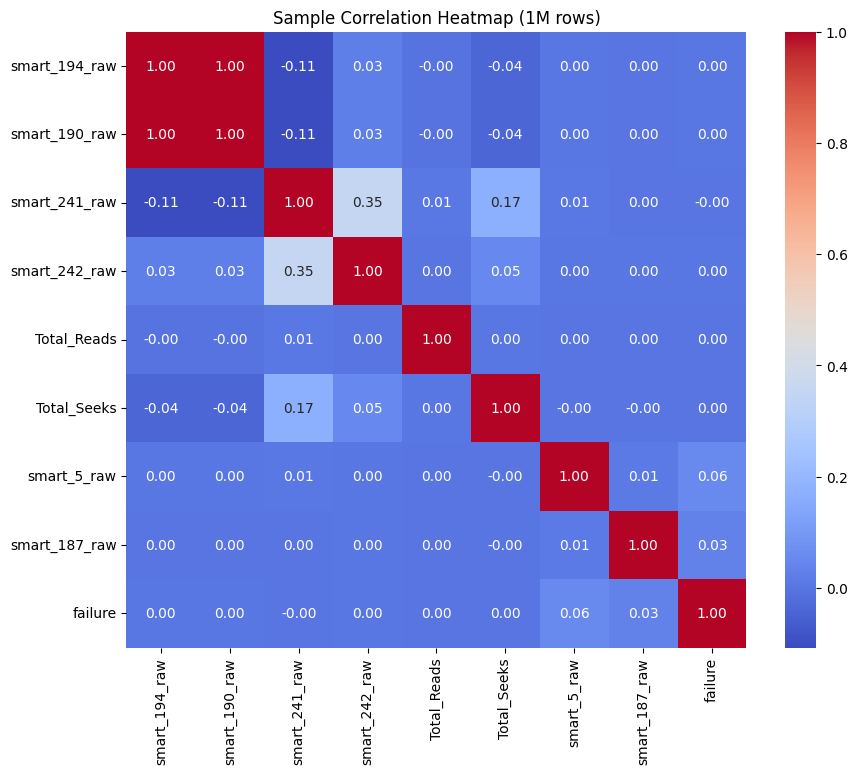


🔍 [Phase 5] 데이터 품질 및 이상치 스캔 중...
⚠️ 주의: 이상 데이터 발견 (수명이 너무 짧거나 온도 센서 오류)
  serial_number  lifespan_days  max_temp  min_temp
0      Z301XH50              3        22        22
1      S300ZAHV              2        19        19
2      W300AYZP              3        25        24
3      W300CVHL              3        24        23
4    S3010LTK_1              4        34        33
5      Z300GPCR              3        23        23
6      Z300GPMG              3        23        21
7    Z302SRG5_5              1        26        26
8    W300A1HY_1              4        17        16
9    W300BNTK_1              4        21        20


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DuckDB 연결 및 데이터 소스 설정
con = duckdb.connect(database=':memory:')
train_path = r'C:\Workspace\06_ML_projdect\26_1_COIN\data\split_group_stratified\train_raw.parquet'

# 가상 뷰 생성 (실제 로드 없이 스캔만 수행)
con.execute(f"CREATE VIEW train_data AS SELECT * FROM read_parquet('{train_path}')")

print("✅ DuckDB View Created. 검증 시작한다!")

# ---------------------------------------------------------
# 🔴 [Phase 1 & 2] 데이터 기초 체력 및 타겟 분포 확인
# ---------------------------------------------------------
print("\n🔍 [Phase 1 & 2] 기초 통계 및 타겟 분포 분석 중...")
phase1_2 = con.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT serial_number) AS unique_disks,
        MIN(date) AS start_date,
        MAX(date) AS end_date,
        SUM(failure) AS total_failures,
        (SUM(failure) * 100.0 / COUNT(*)) AS failure_rate_pct
    FROM train_data
""").df()

print(phase1_2)
# Insight: failure_rate_pct가 0.01% 미만이라면 극심한 불균형 데이터임을 재확인.

# ---------------------------------------------------------
# 🔴 [Phase 3] 핵심 가설 검정 (Seasonality, Sparsity)
# ---------------------------------------------------------
print("\n🔍 [Phase 3] 3대 핵심 가설 검증 중...")

# 가설 1 & 2: 주간 계절성 (I/O vs 온도)
seasonality_check = con.execute("""
    SELECT 
        dayofweek(date) AS dow, -- 0: 일요일, 1: 월요일...
        AVG(smart_241_raw) AS avg_write,
        AVG(Total_Reads) AS avg_read,
        AVG(smart_194_raw) AS avg_temp,
        STDDEV(smart_194_raw) AS std_temp
    FROM train_data
    GROUP BY dow
    ORDER BY dow
""").df()

# 가설 3: 이산형 에러의 희소성 (0의 비율)
sparsity_check = con.execute("""
    SELECT 
        COUNT(*) FILTER (WHERE smart_5_raw = 0) * 100.0 / COUNT(*) AS s5_zero_pct,
        COUNT(*) FILTER (WHERE smart_187_raw = 0) * 100.0 / COUNT(*) AS s187_zero_pct,
        COUNT(*) FILTER (WHERE smart_197_raw = 0) * 100.0 / COUNT(*) AS s197_zero_pct,
        COUNT(*) FILTER (WHERE timeout_total = 0) * 100.0 / COUNT(*) AS timeout_zero_pct
    FROM train_data
""").df()

print("📊 요일별 작업량/온도 변화:")
print(seasonality_check)
print("\n📊 에러 변수 희소성(0의 비율):")
print(sparsity_check)

# ---------------------------------------------------------
# 🟡 [Phase 4] 파생변수 사전 영향도 (상관계수 맛보기)
# ---------------------------------------------------------
print("\n🔍 [Phase 4] 주요 변수 간 상관관계 분석 중...")
# 4,500만 행 전체 상관계수는 무거우므로, 100만 행 샘플링하여 확인
corr_sample = con.execute("""
    SELECT 
        smart_194_raw, smart_190_raw, -- 온도 간
        smart_241_raw, smart_242_raw, Total_Reads, Total_Seeks, -- 작업량 간
        smart_5_raw, smart_187_raw, failure -- 타겟 연관성
    FROM train_data
    USING SAMPLE 1000000
""").df().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_sample, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sample Correlation Heatmap (1M rows)")
plt.show()

# ---------------------------------------------------------
# 🟡 [Phase 5] 데이터 품질 (이상치 및 생존 기간)
# ---------------------------------------------------------
print("\n🔍 [Phase 5] 데이터 품질 및 이상치 스캔 중...")
quality_check = con.execute("""
    SELECT 
        serial_number,
        COUNT(*) AS lifespan_days,
        MAX(smart_194_raw) AS max_temp,
        MIN(smart_194_raw) AS min_temp
    FROM train_data
    GROUP BY serial_number
    HAVING lifespan_days < 7 OR max_temp > 100 OR min_temp < 0
    LIMIT 10
""").df()

if quality_check.empty:
    print("✅ 데이터 품질 양호: 너무 짧은 수명이나 비정상 온도를 가진 디스크가 거의 없습니다.")
else:
    print("⚠️ 주의: 이상 데이터 발견 (수명이 너무 짧거나 온도 센서 오류)")
    print(quality_check)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import time
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pointbiserialr
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 0단계: 메모리 최적화 층화 표본 추출 (DuckDB)
# ==========================================
print("⏳ [0단계] 층화 표본 추출 시작...")
start_time = time.time()

# 파케이 파일 경로 설정 (본인 환경에 맞게 수정)
train_path = r'C:\Workspace\06_ML_projdect\26_1_COIN\data\split_group_stratified\train_raw.parquet'

con = duckdb.connect(database=':memory:')

# 1. 가상 뷰 생성
con.execute(f"CREATE VIEW train_data AS SELECT * FROM read_parquet('{train_path}')")

# 2. 고장 난 디스크(serial_number) 전체 추출
failed_drives_df = con.execute("SELECT DISTINCT serial_number FROM train_data WHERE failure = 1").df()
failed_drives = failed_drives_df['serial_number'].tolist()
n_failures = len(failed_drives)
print(f"  ✅ 고장 발생 디스크 수: {n_failures}개")

# 3. 정상 디스크 샘플링 (고장 디스크의 10배수)
n_normal_samples = n_failures * 10
normal_query = f"""
    SELECT DISTINCT serial_number 
    FROM train_data 
    WHERE failure = 0 
      AND serial_number NOT IN {tuple(failed_drives)}
    USING SAMPLE {n_normal_samples}
"""
normal_drives_df = con.execute(normal_query).df()
normal_drives = normal_drives_df['serial_number'].tolist()
print(f"  ✅ 정상 샘플 디스크 수: {len(normal_drives)}개 (고장의 10배수)")

# 4. 샘플링된 디스크의 전체 시계열 데이터만 Pandas로 로드 (메모리 세이브!)
target_drives = failed_drives + normal_drives
query_final = f"""
    SELECT * FROM train_data 
    WHERE serial_number IN {tuple(target_drives)}
    ORDER BY serial_number, date
"""
df = con.execute(query_final).df()
print(f"✅ 샘플링 완료! 총 행 수: {len(df):,}행 / 소요시간: {time.time() - start_time:.1f}초")


# ==========================================
# 통계량 계산 공통 함수 (코드 중복 방지)
# ==========================================
def calculate_metrics(target_array, label_array):
    """속도 최적화 버전: 내부 샘플링 및 Discrete 플래그 활용"""
    # pandas / numpy / rolling 결과 타입 차이를 흡수하기 위해 1차원 ndarray로 정규화
    x = np.asarray(target_array).reshape(-1)
    y = np.asarray(label_array).reshape(-1)

    # 길이가 어긋난 입력이 들어와도 공통 구간만 사용
    n = min(len(x), len(y))
    if n == 0:
        return 0.0, 0.0
    x = x[:n]
    y = y[:n]

    # NaN/Inf 제거 마스크를 bool ndarray로 강제
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    if len(x_clean) == 0 or len(np.unique(y_clean)) < 2:
        return 0.0, 0.0

    # 1. 포인트 비세리얼 상관계수 (매우 빠름)
    corr, _ = pointbiserialr(y_clean, x_clean)

    # 2. MI 계산 최적화 (여기서 시간 다 잡아먹음)
    # 가설 검정용으로는 10만~20만 행만 있어도 신호 강도는 충분히 나옴
    if len(x_clean) > 200000:
        idx = np.random.choice(len(x_clean), 200000, replace=False)
        x_mi = x_clean[idx]
        y_mi = y_clean[idx]
    else:
        x_mi = x_clean
        y_mi = y_clean

    # discrete_features=True 설정 (이산형 에러 변수일 때 속도 폭발함)
    # 정수형 데이터라면 이 옵션 하나로 KNN 연산을 스킵해서 엄청 빨라짐
    mi = mutual_info_classif(
        x_mi.reshape(-1, 1),
        y_mi,
        discrete_features=True,  # 이산형 데이터일 때 무조건 True!
        random_state=42
    )[0]

    return mi, corr


# ==========================================
# 1단계: 이산형 에러 변수 윈도우 검증
# ==========================================
print("\n" + "="*60)
print("🔍 [1단계] 이산형 변수 윈도우 검증 (3/7일 vs 14/28일)")
print("="*60)

discrete_vars = ['smart_5_raw', 'smart_187_raw', 'smart_184_raw', 'smart_189_raw'] # 주요 에러만 샘플로 테스트
windows = [3, 7, 14, 28]

for var in discrete_vars:
    if var not in df.columns: continue
        
    print(f"\n▶ 【 {var} 】 Sum 정보량 비교")
    
    # 누적값이므로 차분(diff) 계산
    df['diff_temp'] = df.groupby('serial_number')[var].diff().fillna(0)
    df['diff_temp'] = df['diff_temp'].apply(lambda x: max(0, x)) # 음수(노이즈) 제거
    
    results = {}
    for w in windows:
        sum_w = df.groupby('serial_number')['diff_temp'].rolling(w, min_periods=1).sum().values
        mi, corr = calculate_metrics(sum_w, df['failure'].values)
        results[w] = mi
        print(f"   - {w}일: MI = {mi:.5f} / Corr = {corr:.4f}")
    
    # 판정 로직
    max_short = max(results[3], results[7])
    max_long = max(results[14], results[28])
    if max_short < max_long * 0.9:
        print(f"   💡 결론: 단기(3/7일) 유지 불필요 (장기 윈도우 대비 신호 약함)")
    else:
        print(f"   💡 결론: 단기(3/7일) 유지 권장 (순간 폭증 신호 존재)")

df.drop(columns=['diff_temp'], inplace=True, errors='ignore')


# ==========================================
# 2단계: 온도 변수 검증 (Z-score & EWMA)
# ==========================================
print("\n" + "="*60)
print("🔍 [2단계] 온도 변수 단기 지표 필요성 검증")
print("="*60)

temp_vars = ['smart_190_raw', 'smart_194_raw']

for var in temp_vars:
    if var not in df.columns: continue
    print(f"\n▶ 【 {var} 】 Z-score (3일 vs 14/28일)")
    
    # Z-score 검증
    for w in [3, 14, 28]:
        mean_w = df.groupby('serial_number')[var].rolling(w, min_periods=1).mean().values
        std_w = df.groupby('serial_number')[var].rolling(w, min_periods=1).std().values
        zscore = (df[var].values - mean_w) / (std_w + 1e-8)
        
        mi, corr = calculate_metrics(zscore, df['failure'].values)
        print(f"   - Z-score {w}일: MI = {mi:.5f} / Corr = {corr:.4f}")

    print(f"\n▶ 【 {var} 】 EWMA (7일 중복성 검증)")
    for w in [7, 14, 28]:
        ewma = df.groupby('serial_number')[var].ewm(span=w, adjust=False).mean().values
        mi, corr = calculate_metrics(ewma, df['failure'].values)
        print(f"   - EWMA {w}일: MI = {mi:.5f} / Corr = {corr:.4f}")


# ==========================================
# 3단계: 작업량(I/O) 변수 검증
# ==========================================
print("\n" + "="*60)
print("🔍 [3단계] I/O 작업량 7일 추세 필요성 검증")
print("="*60)

io_vars = ['smart_241_raw', 'smart_242_raw', 'Total_Reads', 'Total_Seeks']

for var in io_vars:
    if var not in df.columns: continue
    print(f"\n▶ 【 {var} 】 Sum (7일 vs 14/28일)")
    
    df['diff_temp'] = df.groupby('serial_number')[var].diff().fillna(0)
    df['diff_temp'] = df['diff_temp'].apply(lambda x: max(0, x))
    
    for w in [7, 14, 28]:
        sum_w = df.groupby('serial_number')['diff_temp'].rolling(w, min_periods=1).sum().values
        mi, corr = calculate_metrics(sum_w, df['failure'].values)
        print(f"   - Sum {w}일: MI = {mi:.5f} / Corr = {corr:.4f}")
        
df.drop(columns=['diff_temp'], inplace=True, errors='ignore')

print("\n🎉 모든 가설 검증이 완료되었습니다. 출력된 수치(MI)를 바탕으로 매트릭스를 확정하세요!")

⏳ [0단계] 층화 표본 추출 시작...
  ✅ 고장 발생 디스크 수: 3445개
  ✅ 정상 샘플 디스크 수: 19136개 (고장의 10배수)
✅ 샘플링 완료! 총 행 수: 32,210,306행 / 소요시간: 14.1초

🔍 [1단계] 이산형 변수 윈도우 검증 (3/7일 vs 14/28일)

▶ 【 smart_5_raw 】 Sum 정보량 비교
   - 3일: MI = 0.00033 / Corr = 0.0662
   - 7일: MI = 0.00075 / Corr = 0.0744
   - 14일: MI = 0.00063 / Corr = 0.0797
   - 28일: MI = 0.00075 / Corr = 0.0735
   💡 결론: 단기(3/7일) 유지 권장 (순간 폭증 신호 존재)

▶ 【 smart_187_raw 】 Sum 정보량 비교
   - 3일: MI = 0.00054 / Corr = 0.0108
   - 7일: MI = 0.00079 / Corr = 0.0093
   - 14일: MI = 0.00087 / Corr = 0.0079
   - 28일: MI = 0.00109 / Corr = 0.0060
   💡 결론: 단기(3/7일) 유지 불필요 (장기 윈도우 대비 신호 약함)

▶ 【 smart_184_raw 】 Sum 정보량 비교
   - 3일: MI = 0.00003 / Corr = 0.0326
   - 7일: MI = 0.00008 / Corr = 0.0374
   - 14일: MI = 0.00013 / Corr = 0.0381
   - 28일: MI = 0.00000 / Corr = 0.0449
   💡 결론: 단기(3/7일) 유지 불필요 (장기 윈도우 대비 신호 약함)

▶ 【 smart_189_raw 】 Sum 정보량 비교
   - 3일: MI = 0.00000 / Corr = -0.0000
   - 7일: MI = 0.00000 / Corr = -0.0000
   - 14일: MI = 0.00000 / Corr = -0.0000
   - 2

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices